# Taller Práctico 01 — [Nombre del equipo]

**Curso:** Fundamentos en Ciencia de Datos — Maestría en Ciencia de Datos y Analítica, EAFIT
**Conjunto de datos elegido:** C - Movilidad
**Fecha límite de entrega:** domingo 26 de julio de 2026
**Fecha de entrega real:** [dd/mm/aaaa]

**Integrantes del equipo:**

| Nombre completo | Cédula         |
| --------------- | -------------- |
| Santiago Acevedo Urrego | [N° de cédula] |
| Santiago Betancur | [N° de cédula] |
| Jeronimo Acosta Acevedo | [N° de cédula] |

---


### Tarea 1 — Recolección e inventario de activos (Individual/Diagnóstico)
1. Cargue los tres archivos de su conjunto de datos (`LIMPIO`, `CONTAMINADO`, `.json`) con `pandas`.
2. Construya un inventario: para cada variable, indique tipo de dato (nominal / ordinal /
   discreto / continuo / fecha / geoespacial), formato de origen (CSV, JSON anidado) y si
   proviene de una fuente estructurada o semi-estructurada.
3. Para el JSON: identifique campos anidados o listas (ej. lista de síntomas, diccionarios de
   ubicación) y decida cómo aplanarlos (`pd.json_normalize` o equivalente) para poder cruzarlos
   con el archivo tabular.

**Pregunta de reflexión (obligatoria en Markdown):** ¿qué información se pierde o se distorsiona
al forzar una fuente no estructurada/semi-estructurada dentro de una tabla rectangular?

In [1]:
import sys

# Install the libraries
!{sys.executable} -m pip install matplotlib numpy pandas

# Import the libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd




[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Tarea 1 — Recolección e inventario de activos

#### 1.1. Cargar los tres archivos de su conjunto de datos

Por favor, asegúrate de que los archivos `movilidad_limpio.csv`, `movilidad_contaminado.csv`, y `movilidad.json` estén accesibles en el entorno de Colab. Si están en Google Drive, necesitarás montar Drive primero.

In [2]:
# Cargar archivo 'LIMPIO' (CSV)
try:
    df_limpio = pd.read_csv('Datos/datasets/datasetC_movilidad/movilidad_sensores_LIMPIO.csv')
    print("Archivo 'movilidad_sensores_LIMPIO.csv' cargado exitosamente.")
    display(df_limpio.head())
except FileNotFoundError:
    print("Error: archivo LIMPIO no encontrado. Por favor, verifica la ruta del archivo.")
    df_limpio = pd.DataFrame()

Archivo 'movilidad_sensores_LIMPIO.csv' cargado exitosamente.


,sensor_id,ubicacion,tipo_via,timestamp,conteo_vehiculos,temperatura_c,condicion_clima,lat,lon
0,SEN01,Av. Regional,Troncal,2025-03-01 00:00:00,10,25.3,Soleado,6.23148,-75.58964
1,SEN01,Av. Regional,Troncal,2025-03-01 02:00:00,14,26.8,Soleado,6.22994,-75.59105
2,SEN01,Av. Regional,Troncal,2025-03-01 04:00:00,9,23.8,Soleado,6.23109,-75.59060
3,SEN01,Av. Regional,Troncal,2025-03-01 06:00:00,43,22.5,Soleado,6.23140,-75.59091
4,SEN01,Av. Regional,Troncal,2025-03-01 08:00:00,42,21.2,Lluvia,6.23179,-75.59126


In [3]:
# Cargar archivo 'CONTAMINADO' (CSV)
try:
    df_contaminado = pd.read_csv('Datos/datasets/datasetC_movilidad/movilidad_sensores_CONTAMINADO.csv')
    print("Archivo 'movilidad_sensores_CONTAMINADO.csv' cargado exitosamente.")
    display(df_contaminado.head())
except FileNotFoundError:
    print("Error: archivo CONTAMINADO no encontrado. Por favor, verifica la ruta del archivo.")
    df_contaminado = pd.DataFrame()

Archivo 'movilidad_sensores_CONTAMINADO.csv' cargado exitosamente.


,sensor_id,ubicacion,tipo_via,timestamp,conteo_vehiculos,temperatura_c,condicion_clima,lat,lon
0,SEN03,Calle 10,Local,2025-03-09 16:00:00,31.0,20.7,Soleado,6.20995,-75.57081
1,SEN06,Circular 4ta,Local,2025-03-14 12:00:00,24.0,24.4,Soleado,6.24465,-75.58474
2,SEN04,Autopista Norte,Troncal,2025-03-07 08:00:00,NaN,19.6,Soleado,-75.56538,6.28615
3,SEN01,Av. Regional,Troncal,2025-03-13 04:00:00,16.0,26.3,Soleado,6.23099,-75.58968
4,SEN06,Circular 4ta,Local,2025-03-19 12:00:00,22.0,25.3,Nublado,6.24469,-75.58568


In [4]:
# Cargar y aplanar el JSON semi-estructurado
try:
    import json

    with open('Datos/datasets/datasetC_movilidad/clima_api_log.json', encoding='utf-8') as archivo:
        registros_json = json.load(archivo)

    df_json = pd.DataFrame(registros_json)
    df_json_flattened = pd.json_normalize(registros_json, sep='_')
    print("Archivo 'clima_api_log.json' cargado y aplanado exitosamente.")
    display(df_json_flattened.head())
except FileNotFoundError:
    print("Error: archivo JSON no encontrado. Por favor, verifica la ruta del archivo.")
    df_json = pd.DataFrame()
    df_json_flattened = pd.DataFrame()

Archivo 'clima_api_log.json' cargado y aplanado exitosamente.


,request_id,timestamp,location_sensor_id,location_lat,location_lon,weather_temp_c,weather_condition,weather_humidity_pct
0,W0001,2025-03-17T14:00:00,SEN02,6.2145,-75.5734,26.2,Lluvia,46
1,W0002,2025-03-18T05:00:00,SEN03,6.2093,-75.5710,26.0,Lluvia,44
2,W0003,2025-03-09T18:00:00,SEN01,6.2308,-75.5906,24.1,Soleado,70
3,W0004,2025-03-04T09:00:00,SEN02,6.2145,-75.5734,23.1,Soleado,89
4,W0005,2025-03-02T03:00:00,SEN02,6.2145,-75.5734,21.4,Soleado,58


#### 1.2. Construir un inventario de variables

A continuación, se muestra cómo puedes empezar a construir un inventario para cada DataFrame. Para cada variable, deberás indicar su tipo de dato, formato de origen y si proviene de una fuente estructurada o semi-estructurada. Puedes usar la salida de `info()`, `dtypes` y `describe()` como punto de partida.

##### Inventario para `df_limpio`

In [5]:
if not df_limpio.empty:
    print("Información general de df_limpio:")
    df_limpio.info()
   
else:
    print("df_limpio está vacío. No se puede generar el inventario.")

Información general de df_limpio:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sensor_id         1440 non-null   object 
 1   ubicacion         1440 non-null   object 
 2   tipo_via          1440 non-null   object 
 3   timestamp         1440 non-null   object 
 4   conteo_vehiculos  1440 non-null   int64  
 5   temperatura_c     1440 non-null   float64
 6   condicion_clima   1440 non-null   object 
 7   lat               1440 non-null   float64
 8   lon               1440 non-null   float64
dtypes: float64(3), int64(1), object(5)
memory usage: 101.4+ KB


##### Inventario para `df_contaminado`

In [6]:
if not df_contaminado.empty:
    print("Información general de df_contaminado:")
    df_contaminado.info()
   
else:
    print("df_contaminado está vacío. No se puede generar el inventario.")

Información general de df_contaminado:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1455 entries, 0 to 1454
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sensor_id         1455 non-null   object 
 1   ubicacion         1455 non-null   object 
 2   tipo_via          1455 non-null   object 
 3   timestamp         1455 non-null   object 
 4   conteo_vehiculos  1310 non-null   float64
 5   temperatura_c     1383 non-null   float64
 6   condicion_clima   1368 non-null   object 
 7   lat               1455 non-null   float64
 8   lon               1455 non-null   float64
dtypes: float64(4), object(5)
memory usage: 102.4+ KB


In [7]:
df_json_flattened.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   request_id            120 non-null    object 
 1   timestamp             120 non-null    object 
 2   location_sensor_id    120 non-null    object 
 3   location_lat          120 non-null    float64
 4   location_lon          120 non-null    float64
 5   weather_temp_c        116 non-null    float64
 6   weather_condition     120 non-null    object 
 7   weather_humidity_pct  120 non-null    int64  
dtypes: float64(3), int64(1), object(4)
memory usage: 7.6+ KB


### Inventario de variables

Sin corregir todavía, documenten en una tabla Markdown dentro del notebook:


| Nombre variable  | tipo de dato | formato origen | tipo de fuente  |
| ---------------  | ------------ | ---  | ------------------------- |
| sensor_id        | Nominal | csv  | estructurada              |
| ubicacion        | Nominal | csv  | estructurada              |
| tipo_via         | Nominal | csv  | estructurada              |
| timestamp        | Fecha | csv  | estructurada              |
| conteo_vehiculos | Discreta | csv  | estructurada              |
| temperatura_c    | Continua | csv  | estructurada              |
| condicion_clima  | Nominal | csv  | estructurada              |
| lat              | Geoespacial | csv  | estructurada              |
| lon              | Geoespacial | csv  | estructurada              |
| request_id       | Nominal | json | semi-estructurada         |
| timestamp       | Fecha | json | semi-estructurada         |
| location_sensor_id       | Nominal | json | semi-estructurada         |
| location_lat       | Geoespacial | json | semi-estructurada         |
| location_lon       | Geoespacial | json | semi-estructurada         |
| weather_temp_c       | Continuo | json | semi-estructurada         |
| weather_condition       | Nominal | json | semi-estructurada         |
| weather_humidity_pct       | Continua | json | semi-estructurada         |


#### 1.3. Procesamiento del JSON: Identificar y aplanar campos anidados

Para el JSON, usaremos `pd.json_normalize` para aplanar campos anidados. Es importante inspeccionar la estructura de tu JSON para saber qué campos son anidados y cómo quieres aplanarlos. El siguiente es un ejemplo genérico; puede que necesites ajustarlo a la estructura específica de tu archivo `movilidad.json`.

In [8]:
if not df_json.empty:

    location_df = pd.json_normalize(df_json["location"]).add_prefix("location_")

    weather_df = pd.json_normalize(df_json["weather"]).add_prefix("weather_")

    df_flatted = pd.concat(
        [df_json.drop(columns=["location", "weather"]), location_df, weather_df],
        axis=1
    )

    display(df_flatted.head())
   
else:
    print("df_json está vacío. No se puede procesar el JSON.")

,request_id,timestamp,location_sensor_id,location_lat,location_lon,weather_temp_c,weather_condition,weather_humidity_pct
0,W0001,2025-03-17T14:00:00,SEN02,6.2145,-75.5734,26.2,Lluvia,46
1,W0002,2025-03-18T05:00:00,SEN03,6.2093,-75.5710,26.0,Lluvia,44
2,W0003,2025-03-09T18:00:00,SEN01,6.2308,-75.5906,24.1,Soleado,70
3,W0004,2025-03-04T09:00:00,SEN02,6.2145,-75.5734,23.1,Soleado,89
4,W0005,2025-03-02T03:00:00,SEN02,6.2145,-75.5734,21.4,Soleado,58


### Campos anidados identificados en el JSON
- location: confiene las variables sensor_id, lat, lon.
- weather: contiene las variables temp_c, condition y humidity_pct

#### Pregunta de reflexión (obligatoria en Markdown):

¿Qué información se pierde o se distorsiona al forzar una fuente no estructurada/semi-estructurada dentro de una tabla rectangular?

**Respuesta:**

Al forzar una fuente no estructurada o semi-estructurada (como un JSON con campos anidados o listas) en una tabla rectangular, se pueden perder o distorsionar varios tipos de información:

1.  **Jerarquía y relaciones inherentes:** La estructura jerárquica original del JSON que representa relaciones padre-hijo se pierde. Se reemplaza por una estructura plana donde estas relaciones deben inferirse a través de convenciones de nombres de columnas (ej., `campo_padre.campo_hijo`) o claves primarias/foráneas si se normaliza en múltiples tablas. Esto puede dificultar la comprensión de las relaciones originales de los datos.
2.  **Contexto semántico:** Elementos que están naturalmente agrupados en el formato original pueden ser separados, perdiendo parte de su contexto. Por ejemplo, una lista de eventos dentro de un registro principal, cuando se aplanan, pueden parecer registros independientes, perdiendo la conexión directa con el registro principal del que provienen, a menos que se replique la información del padre.
3.  **Redundancia de datos:** Si una entidad principal tiene múltiples elementos anidados (ej., un usuario con múltiples direcciones), al aplanar, la información del usuario se replicará para cada dirección. Esto introduce redundancia y aumenta el tamaño de la tabla, además de potencialmente dificultar las actualizaciones.
4.  **Información sobre la ausencia de datos:** Un campo que no existe en algunos registros JSON podría representarse como `NaN` (Not a Number) o nulo en la tabla rectangular. Esto podría interpretarse como un dato faltante cuando en realidad, en la fuente original, el campo simplemente no aplicaba o no estaba presente, lo que es una diferencia semántica importante.
5.  **Flexibilidad y granularidad:** Las fuentes semi-estructuradas permiten una gran flexibilidad en la adición de nuevos campos o la variación de la estructura de los registros. Al aplanar a un esquema fijo de tabla, se pierde esta flexibilidad, y cualquier nueva variación en la estructura del JSON requeriría una alteración del esquema de la tabla o un proceso de aplanamiento más complejo.
6.  **Complejidad en consultas:** Ciertas consultas que eran sencillas en el formato original (ej., “dame todos los eventos de este usuario”) pueden volverse más complejas en el formato aplanado, requiriendo uniones o agrupaciones para reconstruir la información original.

En resumen, mientras que el aplanamiento hace que los datos sean accesibles para herramientas y modelos que esperan formatos rectangulares, es crucial ser consciente de las posibles pérdidas y distorsiones semánticas y estructurales que esto implica.

## Tarea 2 — Diagnóstico GIGO sobre el archivo contaminado

In [9]:
display(df_contaminado.describe())
display(df_contaminado.info())

#df_contaminado["condicion_clima"] = df_contaminado["condicion_clima"].str.lower()

valores_unicos = {
    "sensor_id": df_contaminado["sensor_id"].unique(),
    "ubicacion": df_contaminado["ubicacion"].unique(),
    "tipo_via": df_contaminado["tipo_via"].unique(),
    "condicion_clima": df_contaminado["condicion_clima"].unique()
}
display(valores_unicos)

,conteo_vehiculos,temperatura_c,lat,lon
count,1310.000000,1383.000000,1455.000000,1455.000000
mean,328.035878,23.064787,-0.568024,-68.768157
std,5518.158065,2.901087,22.594761,22.612127
min,-5.000000,14.400000,-75.565970,-75.591600
25%,13.000000,21.200000,6.213545,-75.585105
50%,19.000000,23.100000,6.230800,-75.572430
75%,35.000000,25.000000,6.246010,-75.565360
max,99999.000000,31.900000,6.287420,6.287500


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1455 entries, 0 to 1454
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sensor_id         1455 non-null   object 
 1   ubicacion         1455 non-null   object 
 2   tipo_via          1455 non-null   object 
 3   timestamp         1455 non-null   object 
 4   conteo_vehiculos  1310 non-null   float64
 5   temperatura_c     1383 non-null   float64
 6   condicion_clima   1368 non-null   object 
 7   lat               1455 non-null   float64
 8   lon               1455 non-null   float64
dtypes: float64(4), object(5)
memory usage: 102.4+ KB


None

{'sensor_id': array(['SEN03', 'SEN06', 'SEN04', 'SEN01', 'SEN05', 'SEN02'], dtype=object),
 'ubicacion': array(['Calle 10', 'Circular 4ta', 'Autopista Norte', 'Av. Regional',
        'Av. Oriental', 'Av. 33'], dtype=object),
 'tipo_via': array(['Local', 'Troncal', 'Arteria'], dtype=object),
 'condicion_clima': array(['Soleado', 'Nublado', 'Sol', 'Lluvia', 'Nubes', nan, 'soleado',
        'LLUVIA', 'SOLEADO', 'lluvia', 'nublado', 'lluvioso'], dtype=object)}

In [10]:
fechas = pd.to_datetime(df_contaminado["timestamp"], errors="coerce")


invalidas = df_contaminado[fechas.isna()]

print(invalidas)

     sensor_id        ubicacion tipo_via                   timestamp  \
34       SEN06     Circular 4ta    Local                  1740880800   
48       SEN01     Av. Regional  Troncal            13/03/2025 02:00   
100      SEN04  Autopista Norte  Troncal        2025-03-09T06:00:00Z   
103      SEN06     Circular 4ta    Local        2025-03-18T04:00:00Z   
105      SEN05     Av. Oriental  Arteria            19/03/2025 06:00   
...        ...              ...      ...                         ...   
1396     SEN01     Av. Regional  Troncal            12/03/2025 14:00   
1409     SEN06     Circular 4ta    Local            04/03/2025 08:00   
1411     SEN01     Av. Regional  Troncal        2025-03-19T20:00:00Z   
1434     SEN04  Autopista Norte  Troncal  17 de March de 2025, 08:00   
1453     SEN06     Circular 4ta    Local  18 de March de 2025, 20:00   

      conteo_vehiculos  temperatura_c condicion_clima       lat       lon  
34                17.0           19.6         Soleado   6.2

In [11]:

duplicados = df_contaminado[df_contaminado.duplicated(subset=["sensor_id", "timestamp"])]
duplicados = duplicados.sort_values(by=["sensor_id"])
print(duplicados[["sensor_id", "timestamp"]])

     sensor_id            timestamp
188      SEN01  2025-03-09 00:00:00
951      SEN01  2025-03-11 20:00:00
1028     SEN01  2025-03-08 04:00:00
1051     SEN01  2025-03-02 22:00:00
1119     SEN01  2025-03-02 00:00:00
1368     SEN01  2025-03-20 02:00:00
377      SEN02  2025-03-13 12:00:00
1164     SEN02  2025-03-13 16:00:00
1147     SEN04  2025-03-04 22:00:00
1204     SEN04  2025-03-15 00:00:00
998      SEN05  2025-03-11 22:00:00
1109     SEN05  2025-03-06 08:00:00
1168     SEN05  2025-03-03 04:00:00
1263     SEN06  2025-03-08 22:00:00




Sin corregir todavía, documenten en una tabla Markdown dentro del notebook:

| Problema detectado | Columna(s) afectada(s) | Método de detección en pandas | ¿Por qué es un riesgo para la decisión de negocio? |
|---|---|---|---|
| Valores imposibles | conteo_vehiculos | Usando Df.describe() nos muestra que el valor minimo del conteo en -5 y el amximo de 999 lo cual es imposible. | Puede alterar medidas estadisticas como el promedio por ejemplo los cuales son fundamentales a la hora de tomar las deciones de negocio. |
| Consistencia de categorías | condicion_clima | la funcion df["columna"].unique() nos crea una lista con los valores unicos de una columna, donde se evidencia que hay palabras repetidas pero con diferentes combinaciones de mayusculas y minusculas. | na misma condición climática se contabiliza como categorías distintas, afectando los análisis agrupados, las visualizaciones y cualquier modelo que utilice esta variable como predictor. |
| Errores de georreferenciación | lat, long | Se evidencia que hay cordenadas con latitud -75.565970 usando el metodo df.describe() donde este valor aparece como valor minimo, al verificar en el df y introducir en google maps resulta ser que estan inveridas las variables latitud y longitud | Produce una ubicación incorrecta de los sensores o eventos, lo que puede llevar a identificar zonas críticas equivocadas y tomar decisiones erróneas sobre movilidad, mantenimiento o infraestructura. |
| Valores faltantes | conteo_vehiculos, temperatura_c,condicion_clima | Usando el metodo df.describe se evidencia que hay valores faltantes en estas columnas ya que son infereiores a la cantidad del resto de variables que es de 1455 | La ausencia de información reduce la calidad del análisis, puede sesgar los resultados y afectar la precisión de modelos predictivos o indicadores utilizados para la toma de decisiones. |
| Formatos de fecha/hora mixtos | timestamp | se usa el metodo pd.to_datetime para trasformar la fila en fechas y se indica que en caso de tener errores los marque como vacios y luego se imprimen esos errores demostrando que hay valores tanto imposibles como formatos mixtos |mpide ordenar correctamente los eventos en el tiempo, dificulta el análisis temporal y puede provocar errores al calcular tendencias, horarios de mayor tráfico o series de tiempo.|



### Tarea 3 — Transformación y limpieza con pandas
Corrijan cada problema documentado en la Tarea 2. Por cada transformación, el notebook debe
tener: (a) el código, (b) una celda Markdown justificando **la decisión** (no solo la sintaxis).
Ejemplos de decisiones que deben justificar explícitamente:
- ¿Imputar con media, mediana, moda, un valor centinela, o eliminar la fila? ¿Por qué esa y no otra?
- ¿Cómo definieron el rango geográfico válido para Medellín y qué hicieron con las coordenadas
  fuera de rango: corregir automáticamente o descartar?
- ¿Qué llave de negocio usaron para detectar duplicados reales (no solo `.duplicated()` ingenuo)?


In [12]:
#Creamos una copia del dataset contaminado. 
trabajo = df_contaminado.copy()

### Problema: Formatos no validos (Fecha y hora)

Se fuerzan las fechas al formato correcto usando la coerción de pandas (errors="coerce"). Esto convierte la basura en valores nulos que luego son descartados.

In [13]:
# Tipos y formatos
trabajo["timestamp"] = pd.to_datetime(trabajo["timestamp"], errors="coerce")
for columna in ["conteo_vehiculos", "temperatura_c", "lat", "lon"]:
    trabajo[columna] = pd.to_numeric(trabajo[columna], errors="coerce")

### Problema: Categorías inconsistentes

Limpiamos los textos eliminando espacios sobrantes, aplicando mayúsculas iniciales (.str.title()) y utilizando diccionarios manuales para mapear sinónimos a una sola categoría (por ejemplo, homologar "Lluvioso" o "Nubes" a "Lluvia" y "Nublado").

In [14]:
# Estandarización de categorías

for columna in ["ubicacion", "tipo_via", "condicion_clima"]:
    trabajo[columna] = (trabajo[columna].astype("string").str.strip().str.replace(r"\s+", " ", regex=True).str.title())
trabajo["condicion_clima"] = trabajo["condicion_clima"].replace({
    "Lluvioso": "Lluvia", "Soleada": "Soleado", "Sol": "Soleado", "Nubes": "Nublado"
})

### Problema: Duplicados exactos y Duplicados de eventos de negocio

- Duplicados exactos: Eliminamos las filas redundantes con .drop_duplicates() para no inflar los cálculos descriptivos.  

- Duplicados de evento de negocio: Se elimina la duplicidad manteniendo la primera observación válida por cada llave lógica (sensor_id + timestamp).

In [15]:
# Duplicados: se conserva una observación por evento sensor-fecha-hora 
trabajo = trabajo.drop_duplicates().copy()
trabajo = trabajo.drop_duplicates(subset=["sensor_id", "timestamp"], keep="first").copy()

### Problema: Georreferenciación inválida

Coordenadas invertidas: Por errores de captura o del sistema, a veces el valor numérico de la longitud se guarda en la columna de la latitud y viceversa. El código corrige esto automáticamente intercambiando los valores cuando el valor absoluto de la latitud es mayor a 20 y el de la longitud es menor a 20.

Tambien definimos un rango geografico para limitar los valores extremos.


In [16]:
# Validación geográfica aproximada del área metropolitana de Medellín.
# Si lat/lon están invertidas, se corrigen solo cuando el patrón es inequívoco.
coordenadas_invertidas = (trabajo["lat"].abs() > 20) & (trabajo["lon"].abs() < 20)
trabajo.loc[coordenadas_invertidas, ["lat", "lon"]] = trabajo.loc[coordenadas_invertidas, ["lon", "lat"]].to_numpy()
medellin_valida = trabajo["lat"].between(6.15, 6.35) & trabajo["lon"].between(-75.70, -75.50)
trabajo.loc[~medellin_valida, ["lat", "lon"]] = np.nan

### Problema: Conteos o temperaturas fuera de rango

Filtramos lógicamente los datos operativos. Definimos que los vehículos deben estar en el rango de 0 a 5,000 (ya que es un conteo por intervalo, no diario) y la temperatura de -10 a 45 grados Celsius. Todo lo que escape de allí se vuelve nulo y se imputa con la mediana.

In [17]:
# Valores imposibles se convierten en faltantes; el límite de 5.000 vehículos
# corresponde a un conteo operativo por intervalo, no a un acumulado diario.
trabajo.loc[~trabajo["conteo_vehiculos"].between(0, 5000), "conteo_vehiculos"] = np.nan
trabajo.loc[~trabajo["temperatura_c"].between(-10, 45), "temperatura_c"] = np.nan

### Problema: Valores faltantes

- Valores numéricos (conteo_vehiculos, temperatura_c): Debemos imputar con la mediana. Al observar las estadísticas descriptivas de los datos contaminados: la columna de conteo de vehículos tiene valores atípicos extremos, con un máximo imposible de 99,999 y un mínimo de -5. Esto jala la media a un valor distorsionado de 328.03, mientras que la mediana se sitúa de forma realista en 19.0. La mediana es robusta ante estos valores atípicos.

- Variables categóricas (ubicacion, tipo_via, condicion_clima): Imputaremos con la moda, rellenando los vacíos con la categoría más frecuente. Esto se debe a que las variables categoricas no tienen ni media ni mediana. Al llenar con la moda, continuamos el patron de repeticion.

- Identificadores estructurales (timestamp, lat, lon): Se debe eliminar la fila. Inventar fechas o coordenadas sin evidencia suficiente distorsiona la realidad y no aporta al análisis espacial temporal.


In [18]:
# Imputación
for columna in ["conteo_vehiculos", "temperatura_c"]:
    trabajo[columna] = trabajo[columna].fillna(trabajo[columna].median())
for columna in ["ubicacion", "tipo_via", "condicion_clima"]:
    trabajo[columna] = trabajo[columna].fillna(trabajo[columna].mode().iloc[0])


# Fechas o coordenadas sin evidencia suficiente no se inventan: se excluyen del análisis.
df_trabajo = trabajo.dropna(subset=["timestamp", "lat", "lon"]).copy()
df_trabajo["hora"] = df_trabajo["timestamp"].dt.hour
df_trabajo["dia_semana"] = df_trabajo["timestamp"].dt.day_name(locale="es_ES")

print(f"Filas contaminadas: {len(df_contaminado):,}")
print(f"Filas disponibles después de limpiar: {len(df_trabajo):,}")
display(df_trabajo.head())


Filas contaminadas: 1,455
Filas disponibles después de limpiar: 1,351


,sensor_id,ubicacion,tipo_via,timestamp,conteo_vehiculos,temperatura_c,condicion_clima,lat,lon,hora,dia_semana
0,SEN03,Calle 10,Local,2025-03-09 16:00:00,31.0,20.7,Soleado,6.20995,-75.57081,16,Domingo
1,SEN06,Circular 4Ta,Local,2025-03-14 12:00:00,24.0,24.4,Soleado,6.24465,-75.58474,12,Viernes
2,SEN04,Autopista Norte,Troncal,2025-03-07 08:00:00,19.0,19.6,Soleado,6.28615,-75.56538,8,Viernes
3,SEN01,Av. Regional,Troncal,2025-03-13 04:00:00,16.0,26.3,Soleado,6.23099,-75.58968,4,Jueves
4,SEN06,Circular 4Ta,Local,2025-03-19 12:00:00,22.0,25.3,Nublado,6.24469,-75.58568,12,Miércoles



### Tarea 4 — Analítica descriptiva cuantitativa, cualitativa y gráfica
Sobre los datos ya limpios (los suyos, no el archivo `_LIMPIO.csv` de referencia):
1. **Cuantitativa:** medidas de tendencia central y dispersión para al menos 2 variables continuas
   y 1 discreta, con la medida correcta según su distribución (¿usarían media o mediana? ¿por qué?).
2. **Cualitativa:** tablas de frecuencia/proporción para al menos 2 variables categóricas,
   incluyendo el cruce (tabla de contingencia) entre una variable categórica y la variable
   ordinal o de resultado de su conjunto de datos.
3. **Gráfica:** mínimo 3 visualizaciones distintas (ej. barras, histograma/densidad, dispersión o
   mapa de puntos con `lat`/`lon`), cada una con una conclusión de una frase — no basta con
   mostrar el gráfico.


,count,mean,median,std,min,max,tipo
temperatura_c,1351.0,23.068764,23.10000,2.859000,14.40000,31.9000,continua
lat,1351.0,6.238610,6.23174,0.025472,6.20832,6.2875,continua
conteo_vehiculos,1351.0,22.450777,19.00000,12.481289,0.00000,54.0000,discreta


Frecuencia y proporción por ubicación:


,frecuencia,proporcion
ubicacion,,
Calle 10,229,0.169504
Circular 4Ta,227,0.168024
Av. 33,226,0.167283
Av. Regional,225,0.166543
Autopista Norte,222,0.164323
Av. Oriental,222,0.164323


Frecuencia y proporción por condición climática:


,frecuencia,proporcion
condicion_clima,,
Soleado,747,0.552924
Nublado,405,0.299778
Lluvia,199,0.147298


Cruce entre tipo de vía y nivel ordinal de tráfico:


nivel_trafico,Bajo,Medio,Alto
tipo_via,,,
Arteria,0.400,0.290,0.310
Local,0.344,0.329,0.327
Troncal,0.367,0.309,0.324


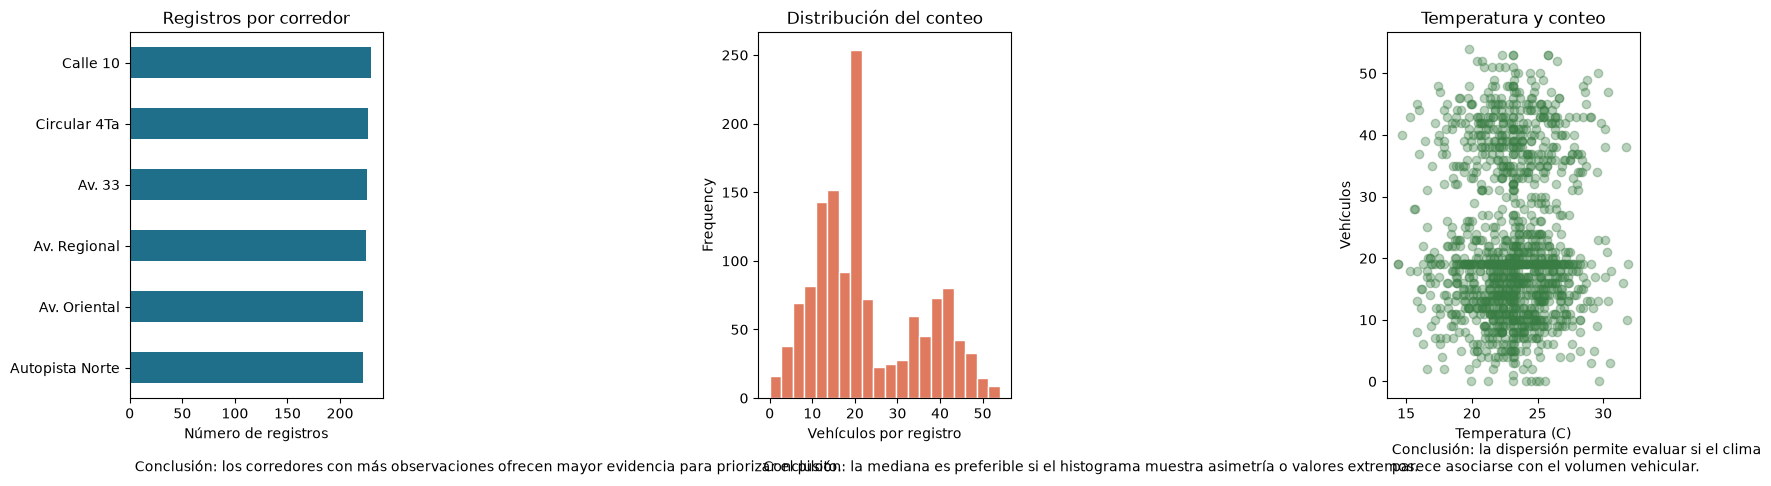

In [19]:
# Analítica descriptiva sobre df_trabajo, reconstruido desde el contaminado
variables_numericas = ["temperatura_c", "lat", "conteo_vehiculos"]
resumen_numerico = df_trabajo[variables_numericas].agg(["count", "mean", "median", "std", "min", "max"]).T
resumen_numerico["tipo"] = ["continua", "continua", "discreta"]
display(resumen_numerico)

print("Frecuencia y proporción por ubicación:")
frecuencia_ubicacion = df_trabajo["ubicacion"].value_counts().to_frame("frecuencia")
frecuencia_ubicacion["proporcion"] = frecuencia_ubicacion["frecuencia"] / len(df_trabajo)
display(frecuencia_ubicacion)

print("Frecuencia y proporción por condición climática:")
frecuencia_clima = df_trabajo["condicion_clima"].value_counts().to_frame("frecuencia")
frecuencia_clima["proporcion"] = frecuencia_clima["frecuencia"] / len(df_trabajo)
display(frecuencia_clima)

# El conteo se convierte en una variable ordinal para cruzarlo con el tipo de vía.
df_trabajo["nivel_trafico"] = pd.qcut(
    df_trabajo["conteo_vehiculos"],
    q=3,
    labels=["Bajo", "Medio", "Alto"],
    duplicates="drop"
)
print("Cruce entre tipo de vía y nivel ordinal de tráfico:")
display(pd.crosstab(df_trabajo["tipo_via"], df_trabajo["nivel_trafico"], normalize="index").round(3))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
frecuencia_ubicacion["frecuencia"].sort_values().plot(kind="barh", ax=axes[0], color="#1f6f8b", title="Registros por corredor")
axes[0].set_xlabel("Número de registros")
axes[0].set_ylabel("")
axes[0].text(0.02, -0.20, "Conclusión: los corredores con más observaciones ofrecen mayor evidencia para priorizar el piloto.", transform=axes[0].transAxes, wrap=True)

df_trabajo["conteo_vehiculos"].plot(kind="hist", bins=20, ax=axes[1], color="#e07a5f", edgecolor="white", title="Distribución del conteo")
axes[1].set_xlabel("Vehículos por registro")
axes[1].text(0.02, -0.20, "Conclusión: la mediana es preferible si el histograma muestra asimetría o valores extremos.", transform=axes[1].transAxes, wrap=True)

axes[2].scatter(df_trabajo["temperatura_c"], df_trabajo["conteo_vehiculos"], alpha=0.35, color="#3a7d44")
axes[2].set_title("Temperatura y conteo")
axes[2].set_xlabel("Temperatura (C)")
axes[2].set_ylabel("Vehículos")
axes[2].text(0.02, -0.20, "Conclusión: la dispersión permite evaluar si el clima parece asociarse con el volumen vehicular.", transform=axes[2].transAxes, wrap=True)
plt.tight_layout()
plt.show()



### Tarea 5 — De la estadística a la decisión
Cierre el notebook con una sección `## Decisión Recomendada` que responda:
1. ¿Cuál es la pregunta de negocio que este análisis realmente responde? (recuerden el ejercicio
   de la Sesión 1: "no es *cuánto*, sino *cuál es la probabilidad de que*...").
2. ¿Cuál es la recomendación concreta y accionable?
3. ¿Qué le costaría a la organización un Falso Positivo y un Falso Negativo en esta decisión?
4. ¿Qué limitación de los datos (algo que ni siquiera la limpieza pudo resolver) debe quedar
   explícita para quien tome la decisión?


In [20]:
# Decisión Recomendada: priorización basada en la probabilidad observada de tráfico alto
resumen_decision = (
    df_trabajo.groupby(["ubicacion", "hora"], as_index=False)
    .agg(
        registros=("conteo_vehiculos", "size"),
        conteo_promedio=("conteo_vehiculos", "mean"),
        probabilidad_trafico_alto=("nivel_trafico", lambda serie: (serie == "Alto").mean())
    )
    .sort_values(["probabilidad_trafico_alto", "conteo_promedio"], ascending=False)
)

mejor_piloto = resumen_decision.iloc[0]
print("## Decisión Recomendada")
print(
    f"Pregunta de negocio: ¿cuál es la probabilidad de observar tráfico alto "
    f"por corredor y hora para priorizar un piloto de semaforización inteligente?"
)
print(
    f"Recomendación: iniciar el piloto en {mejor_piloto['ubicacion']} a las "
    f"{int(mejor_piloto['hora']):02d}:00, donde la proporción observada de tráfico alto "
    f"es {mejor_piloto['probabilidad_trafico_alto']:.1%} en {int(mejor_piloto['registros'])} registros."
)
print("Falso positivo: invertir en infraestructura y operación en una franja que no genere mejoras suficientes.")
print("Falso negativo: no intervenir una franja crítica, manteniendo demoras, emisiones y riesgo de congestión.")
print("Limitación: los datos son observaciones históricas de marzo y no incluyen tiempos de viaje, accidentes ni eventos especiales.")

display(resumen_decision.head(10))


## Decisión Recomendada
Pregunta de negocio: ¿cuál es la probabilidad de observar tráfico alto por corredor y hora para priorizar un piloto de semaforización inteligente?
Recomendación: iniciar el piloto en Av. Oriental a las 16:00, donde la proporción observada de tráfico alto es 100.0% en 19 registros.
Falso positivo: invertir en infraestructura y operación en una franja que no genere mejoras suficientes.
Falso negativo: no intervenir una franja crítica, manteniendo demoras, emisiones y riesgo de congestión.
Limitación: los datos son observaciones históricas de marzo y no incluyen tiempos de viaje, accidentes ni eventos especiales.


,ubicacion,hora,registros,conteo_promedio,probabilidad_trafico_alto
32,Av. Oriental,16,19,40.315789,1.000000
21,Av. 33,18,19,39.684211,1.000000
45,Av. Regional,18,19,39.315789,1.000000
57,Calle 10,18,19,39.315789,1.000000
40,Av. Regional,8,18,38.722222,1.000000
9,Autopista Norte,18,20,39.350000,0.950000
56,Calle 10,16,19,38.789474,0.947368
28,Av. Oriental,8,18,38.500000,0.944444
51,Calle 10,6,18,37.555556,0.944444
64,Circular 4Ta,8,17,39.000000,0.941176
